In [89]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import scipy.cluster.hierarchy as sch
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score,  davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [90]:
#Import Dataset
df = pd.read_csv('Customer Segmentation.csv')

In [91]:
# Dataset Overview - Shape
df.shape

(2627, 10)

In [92]:
# Dataset Overview - First 5 rows
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [93]:
# Dataset Overview - Data types, Number of non-null entries, and Memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB


In [94]:
# Dataset Overview - Summary Stats
df.describe(include='all')

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
count,2627.000000,2627,2577,2627.000000,2603,2589,2358.000000,2627,2514.000000,2595
unique,NaN,2,2,NaN,2,9,NaN,3,NaN,7
top,NaN,Male,Yes,NaN,Yes,Artist,NaN,Low,NaN,Cat_6
freq,NaN,1424,1520,NaN,1602,802,NaN,1616,NaN,1672
mean,463433.918919,NaN,NaN,43.649791,NaN,NaN,2.552587,NaN,2.825378,NaN
std,2618.245698,NaN,NaN,16.967015,NaN,NaN,3.341094,NaN,1.551906,NaN
min,458989.000000,NaN,NaN,18.000000,NaN,NaN,0.000000,NaN,1.000000,NaN
25%,461162.500000,NaN,NaN,30.000000,NaN,NaN,0.000000,NaN,2.000000,NaN
50%,463379.000000,NaN,NaN,41.000000,NaN,NaN,1.000000,NaN,2.000000,NaN
75%,465696.000000,NaN,NaN,53.000000,NaN,NaN,4.000000,NaN,4.000000,NaN


In [95]:
# EDA & Pre-processing - Check missing values
df.isnull()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
2622,False,False,False,False,False,False,False,False,False,False
2623,False,False,False,False,False,False,False,False,False,False
2624,False,False,False,False,False,False,True,False,False,False
2625,False,False,False,False,False,False,False,False,False,False


In [96]:
# EDA & Pre-processing
print(df.isnull().sum()) # Sum of missing values

ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience    269
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64


In [97]:
# EDA & Pre-processing - Fill missing values
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist() # Numerical columns

df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean()) # Mean

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist() # Categorical columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0]) #Mode

In [98]:
# EDA & Pre-processing - Check if any missing value left
print(df.isnull().sum())

ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64


In [99]:
# EDA & Pre-processing
df_clean = df.copy() # create copy of original dataset

# Drop ID column
if 'ID' in df_clean.columns:
    df_clean.drop(columns=['ID'], inplace=True)
sp_map = {'Low': 0, 'Average': 1, 'High': 2}

# Convert Spending_Score colmuns values to numeric
if 'Spending_Score' in df_clean.columns:
    df_clean['Spending_Score_ord'] = df_clean['Spending_Score'].map(sp_map)

# Assign variables to numeric and categorical features
numeric_features = ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_ord']
categorical_features = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Var_1']

In [100]:
# # EDA & Pre-processing 
# Pipeline for processing numerical features
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for processing categorical features
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Transformer for both numeric and categorical features
preprocessor = ColumnTransformer([
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])

In [101]:
# EDA & Pre-processing
# Save transformed features into X
X = preprocessor.fit_transform(df_clean)
print('Processed data shape:', X.shape)

Processed data shape: (2627, 26)


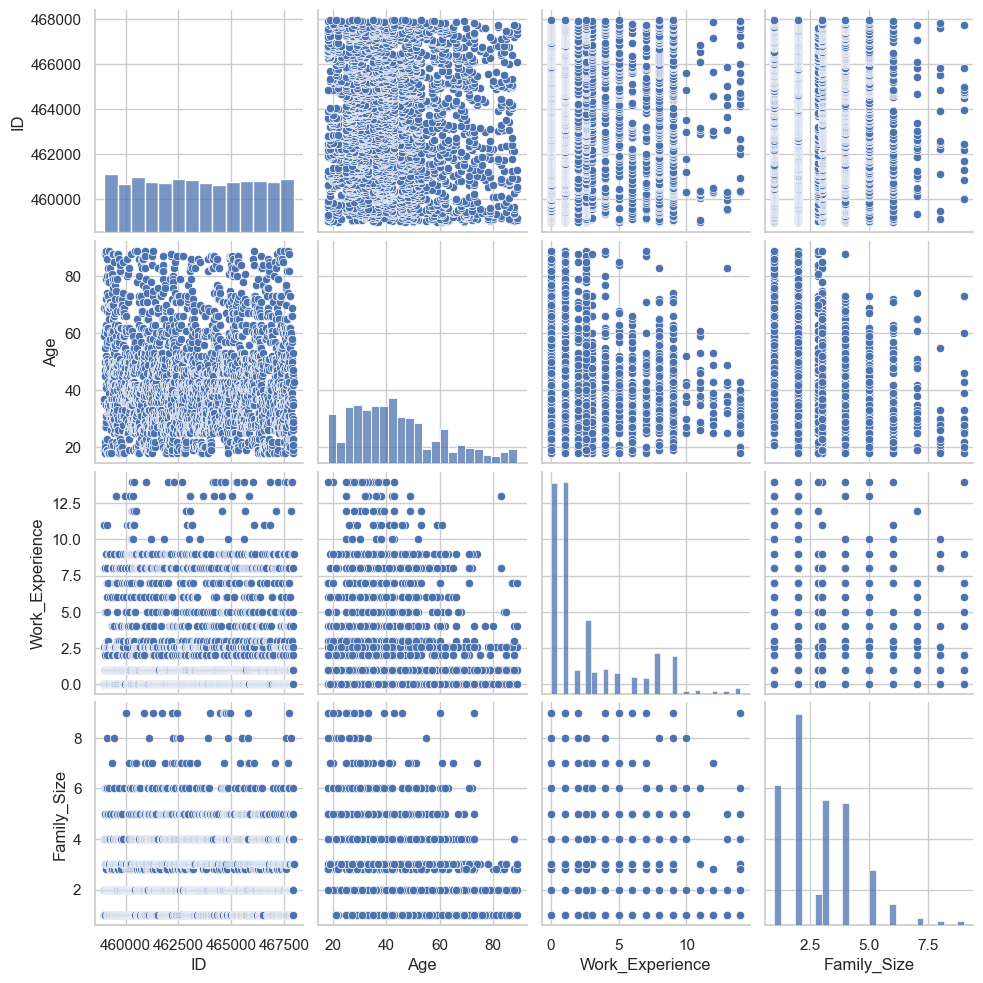

In [102]:
# EDA & Pre-processing
# Pairplot of numeric features
sns.pairplot(df.iloc[:,[0,1,2,3,4,5,6,7,8]])

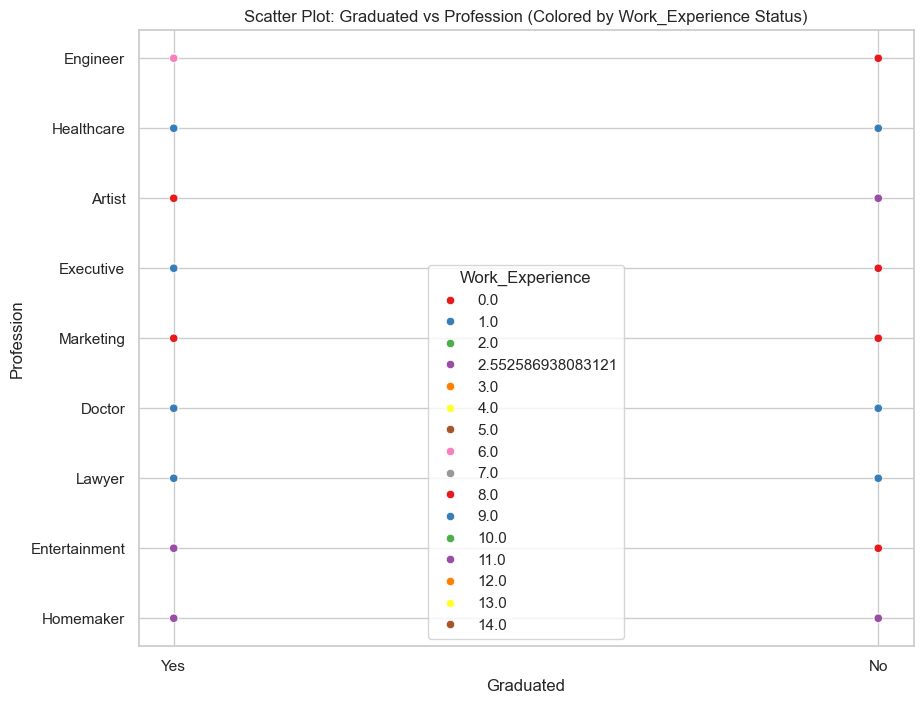

In [103]:
# EDA & Pre-processing
# Scatter plot: Graduate vs Profession feature
plt.figure(figsize=(10,8))
sns.scatterplot(x='Graduated', y='Profession', data=df, hue='Work_Experience', palette='Set1')
plt.title('Scatter Plot: Graduated vs Profession (Colored by Work_Experience Status)')
plt.xlabel('Graduated')
plt.ylabel('Profession')
plt.legend(title='Work_Experience')
plt.show()

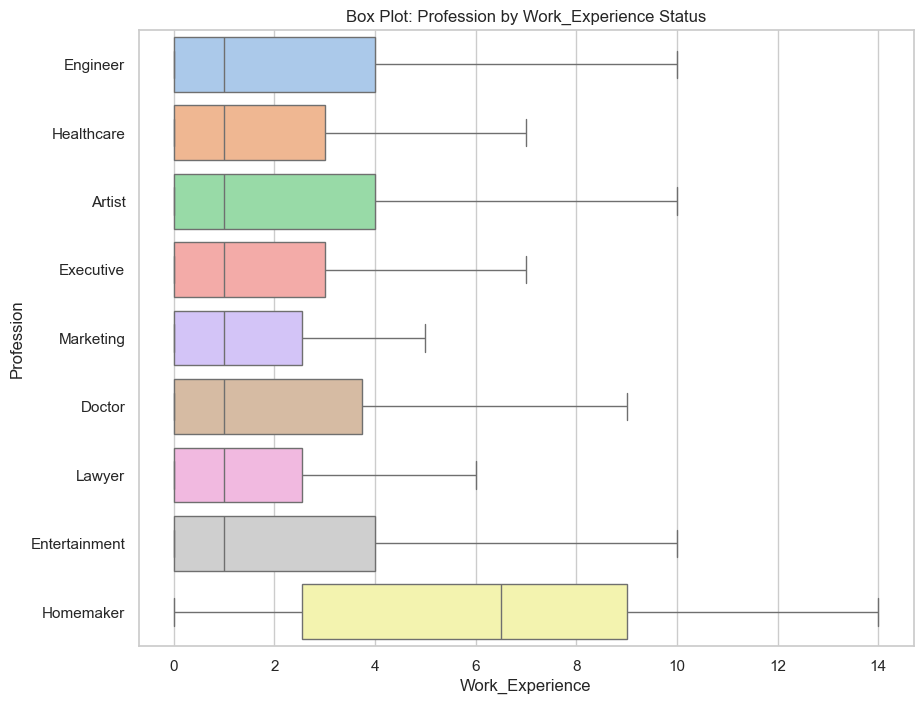

In [104]:
# EDA & Pre-processing
# Box Plot: Profession by Work_Experience Status
plt.figure(figsize=(10,8))
sns.boxplot(x='Work_Experience', y='Profession', data=df, palette='pastel', hue='Profession', showfliers=False)
plt.title('Box Plot: Profession by Work_Experience Status')
plt.xlabel('Work_Experience')
plt.ylabel('Profession')
plt.show()

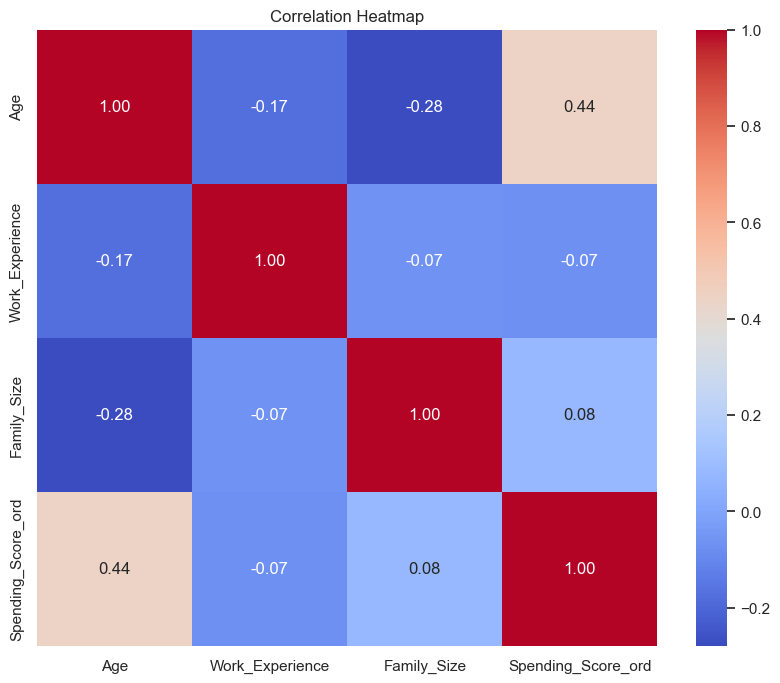

In [105]:
# EDA & Pre-processing
# Correlation heatmap of numeric features
numeric_features = ['Age', 'Work_Experience', 'Family_Size', 'Spending_Score_ord']

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[numeric_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [106]:
# EDA & Pre-processing
optimal_k = 3 # Set the number of clusters to 3

# Features to use for clustering
features = ["ID", "Gender", "Ever_Married", "Age", "Graduated",
            "Profession", "Work_Experience", "Spending_Score",
            "Family_Size", "Var_1"]

#Create a copy again
X = df[features].copy()

# Detect categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns being encoded:", categorical_cols)

# Apply One-Hot encoding to the categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

Categorical columns being encoded: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


In [107]:
# Initialize two empty lists to store Within-Cluster Sum of Squares
wcss, sil = [], []

# Loop over different values of k
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # Initialize KMeans clustering model with k clusters
    labels = km.fit_predict(X_scaled)  # Fit the model
    wcss.append(km.inertia_)  # Append the silhouette score for the current k
    sil.append(silhouette_score(X_scaled, labels))  # Silhouette score

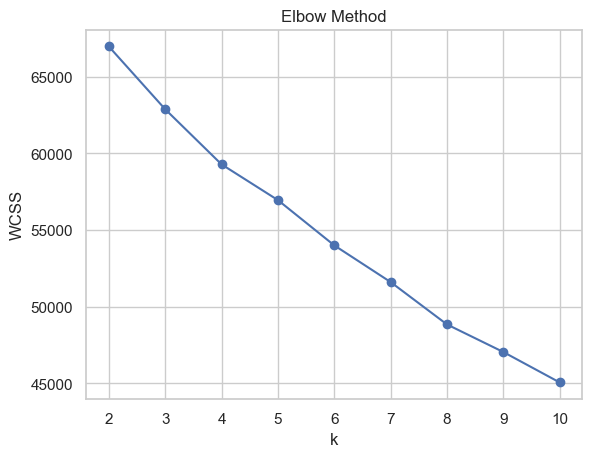

In [108]:
# Plot Elbow Method
plt.plot(range(2, 11), wcss, '-o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

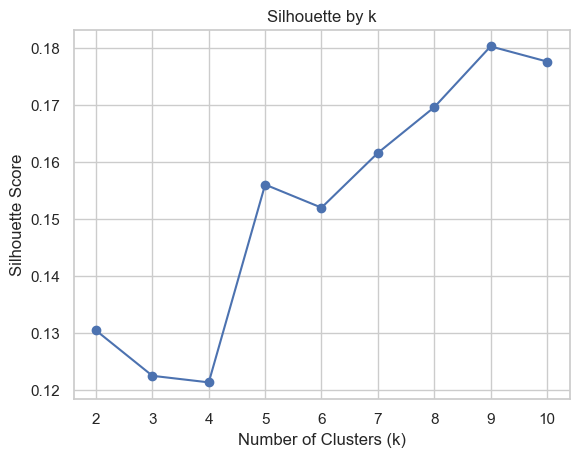

In [109]:
# Plot Silhouette Scores for different k values
plt.plot(range(2, 11), sil, '-o')
plt.title("Silhouette by k")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [110]:
# Model building - Initialize KMeans model
km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_kmeans = km.fit_predict(X_scaled)

silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans) # Calculate Silhouette Score for KMeans
davies_bouldin_kmeans = davies_bouldin_score(X_scaled, labels_kmeans) # Calculate Davies-Bouldin Index for KMeans

print(f"KMeans Silhouette Score: {silhouette_kmeans}")
print(f"KMeans Davies-Bouldin Index: {davies_bouldin_kmeans}")

KMeans Silhouette Score: 0.12248327451189844
KMeans Davies-Bouldin Index: 2.6250361888874925


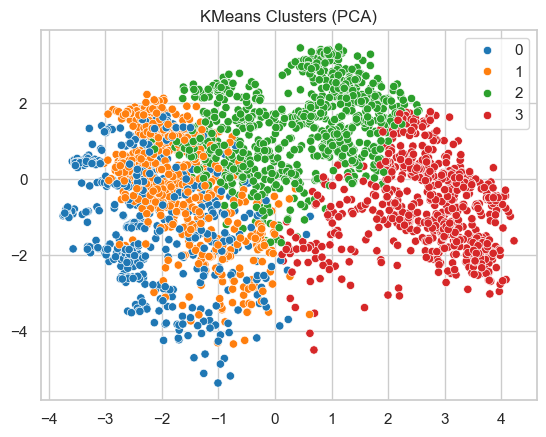

       ID  KMeans
0  458989       2
1  458994       1
2  458996       2
3  459000       0
4  459001       3


In [111]:
# Model building - Initialize the KMeans model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X_scaled) # Fit the KMeans model on the scaled data (X_scaled)

df['KMeans'] = k_labels

# Visualization settings
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=k_labels, palette='tab10')
plt.title('KMeans Clusters (PCA)')
plt.show()

print(df[['ID', 'KMeans']].head())

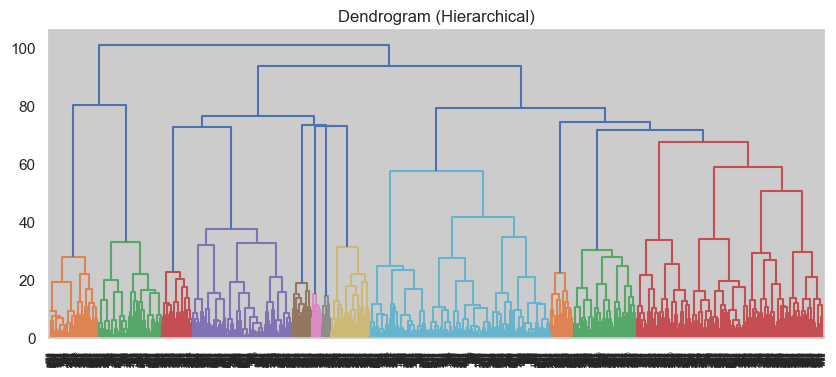

       ID  Agglomerative
0  458989              0
1  458994              2
2  458996              0
3  459000              3
4  459001              2


In [112]:
# Model building - Apply Agglomerative Clustering using Ward linkage method
Z = linkage(X_scaled, method='ward')

# Visualization settings
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='level', p=30)
plt.title('Dendrogram (Hierarchical)')
plt.show()

# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled)

df['Agglomerative'] = agg_labels

print(df[['ID', 'Agglomerative']].head())

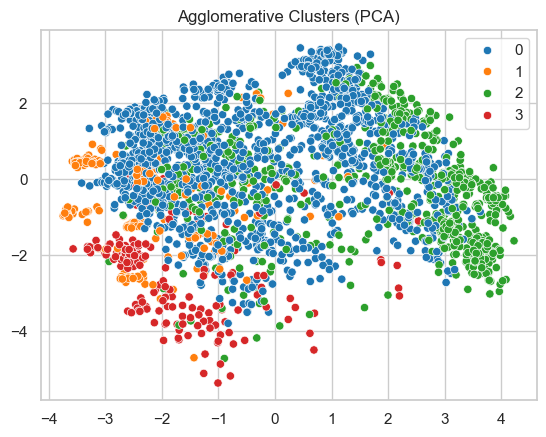

In [113]:
# Model building - Agglomerative Clusters
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels, palette='tab10')
plt.title('Agglomerative Clusters (PCA)')
plt.show()

In [114]:
# Model building
# Calculate Silhouette Score & Davies-Bouldin Index for KMeans clustering
silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans) 
davies_bouldin_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)

# Calculate Silhouette Score & Davies-Bouldin Index for Agglomerative clustering
silhouette_agg = silhouette_score(X_scaled, agg_labels)
davies_bouldin_agg = davies_bouldin_score(X_scaled, agg_labels)

print(f"K-Means Silhouette Score: {silhouette_kmeans}")
print(f"Agglomerative Silhouette Score: {silhouette_agg}")
print(f"K-Means Davies-Bouldin Index: {davies_bouldin_kmeans}")
print(f"Agglomerative Davies-Bouldin Index: {davies_bouldin_agg}")

K-Means Silhouette Score: 0.12248327451189844
Agglomerative Silhouette Score: 0.11845183955237974
K-Means Davies-Bouldin Index: 2.6250361888874925
Agglomerative Davies-Bouldin Index: 2.50472834773771


In [115]:
# Select numeric columns from DataFrame
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Gathered data by KMeans cluster labels
cluster_means = df.groupby('KMeans')[numeric_cols].mean()

print(cluster_means) 

                   ID        Age  Work_Experience  Family_Size  KMeans  \
KMeans                                                                   
0       463405.203187  62.657371         1.982537     2.699266     0.0   
1       463570.729469  47.123994         2.286884     3.065588     1.0   
2       463249.960241  42.319277         3.185538     2.003843     2.0   
3       463555.790801  27.930267         2.442523     3.709669     3.0   

        Agglomerative  
KMeans                 
0            1.372510  
1            0.357488  
2            0.392771  
3            1.330861  


K-Means Silhouette Score: 0.1280
Agglomerative Silhouette Score: 0.1012
K-Means Davies-Bouldin Index: 2.3147
Agglomerative Davies-Bouldin Index: 3.0276


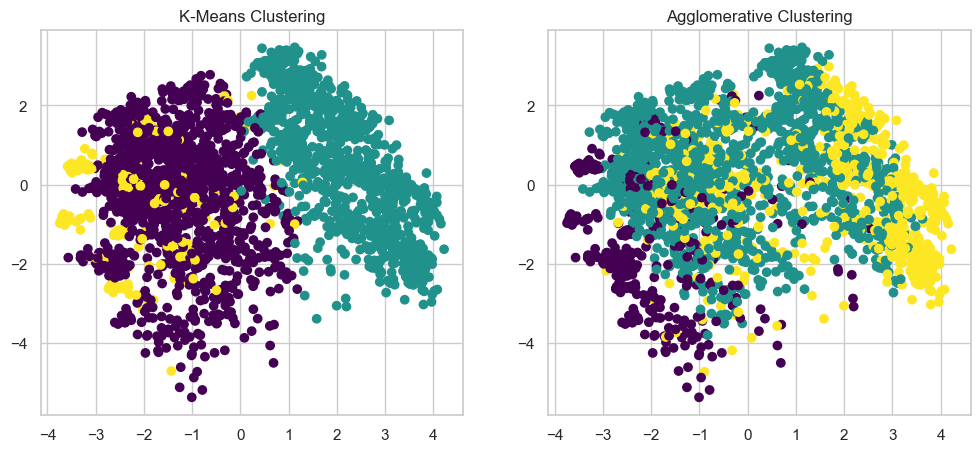

In [116]:
#Comparison of both models
# Initialize both clustering models with the same number of clusters (3)
kmeans = KMeans(n_clusters=3, random_state=42)
agglomerative = AgglomerativeClustering(n_clusters=3)

# Fit both models on scaled feature matrix
kmeans.fit(X_scaled)
agglomerative.fit(X_scaled)

# Calculate Silhouette Score for both models
kmeans_silhouette = silhouette_score(X_scaled, kmeans.labels_)
agglomerative_silhouette = silhouette_score(X_scaled, agglomerative.labels_)

# Calculate Davies-Bouldin Index for both models
kmeans_db = davies_bouldin_score(X_scaled, kmeans.labels_)
agglomerative_db = davies_bouldin_score(X_scaled, agglomerative.labels_)

# Print both evaluation metrics for comparison
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Agglomerative Silhouette Score: {agglomerative_silhouette:.4f}")
print(f"K-Means Davies-Bouldin Index: {kmeans_db:.4f}")
print(f"Agglomerative Davies-Bouldin Index: {agglomerative_db:.4f}")

# Perform PCA to reduce data to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title('K-Means Clustering')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglomerative.labels_, cmap='viridis')
plt.title('Agglomerative Clustering')

plt.show() # Display comparison plots

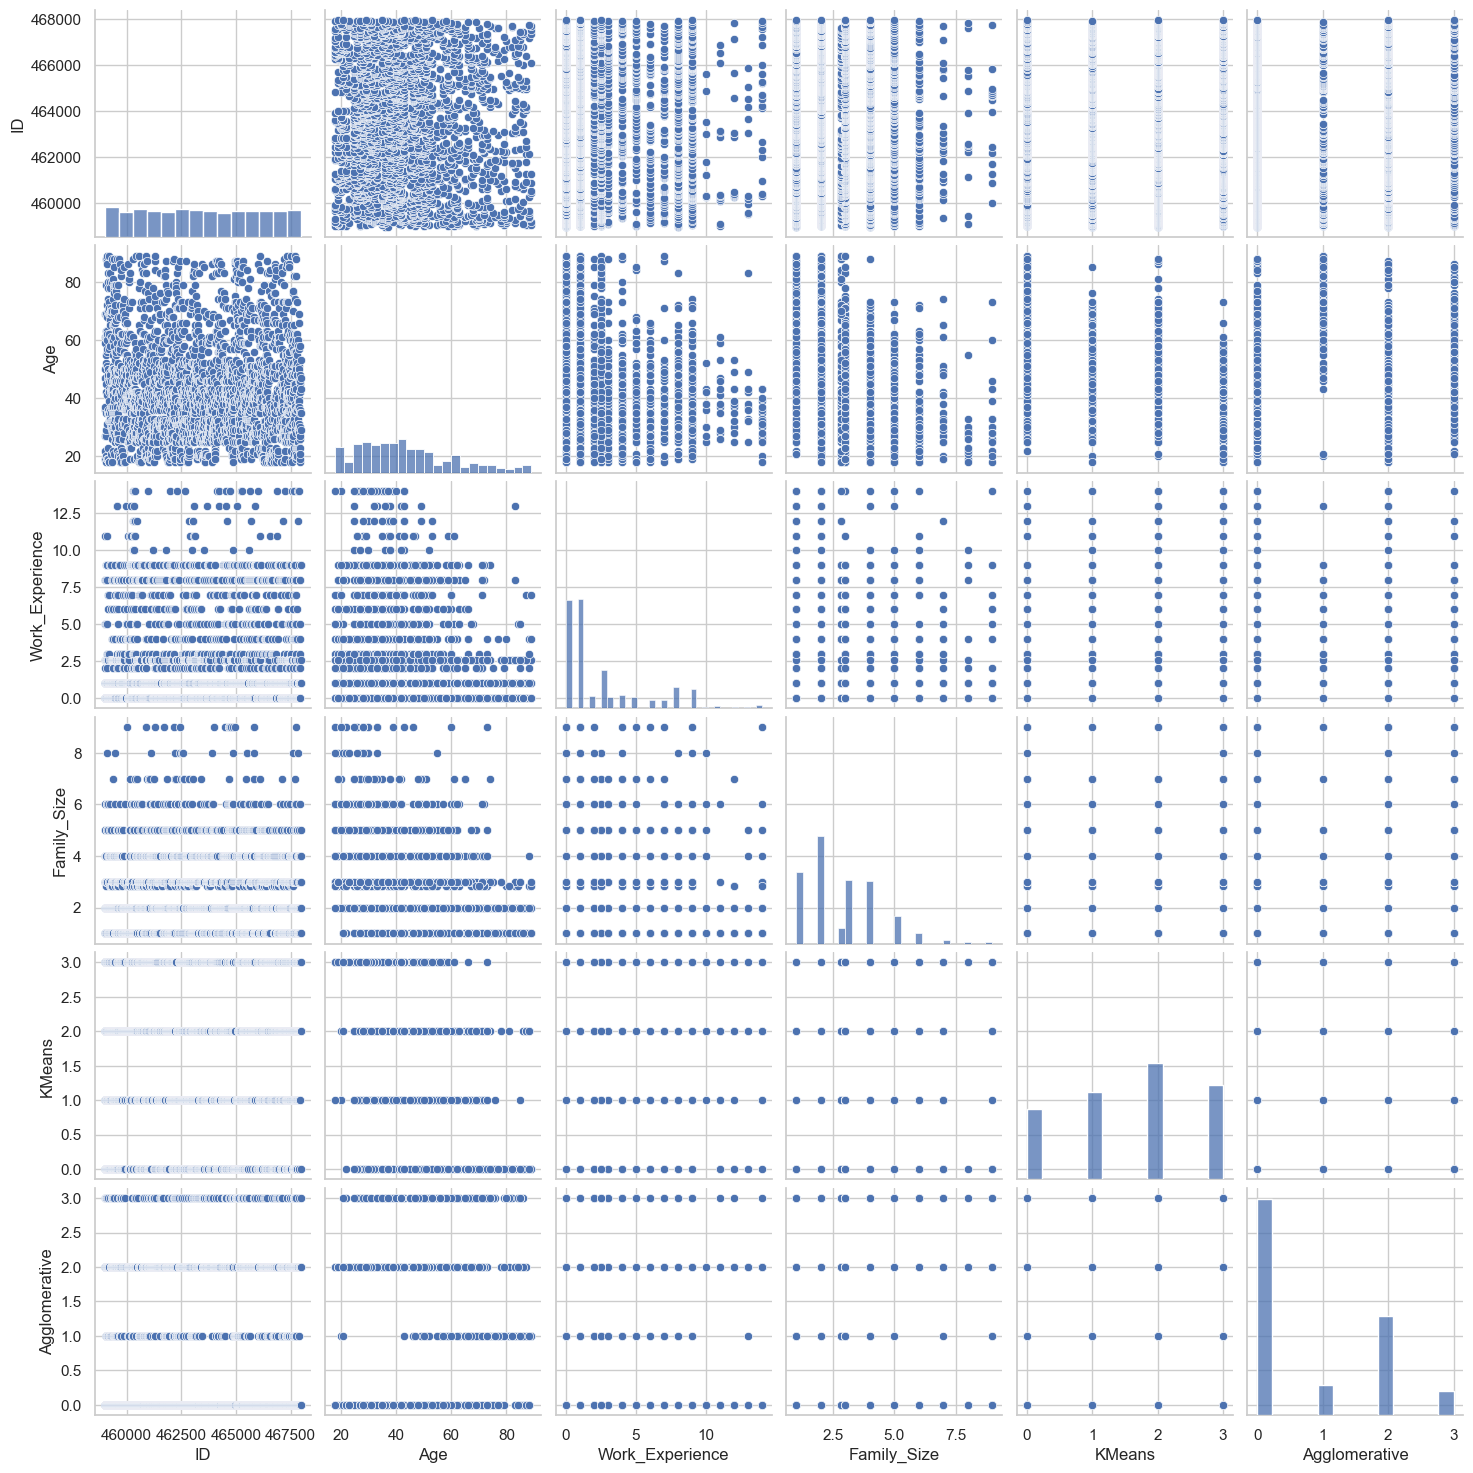

In [117]:
# Pairplot including KMeans and Agglomerative clusters column 
sns.pairplot(df.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11]])